In [34]:
import cv2
import numpy as np
# 1) Provide your image path here (change to your file path)
IMG_PATH = "spine.jpg"
# 2) Read as grayscale (IMREAD_GRAYSCALE => 2D array)
img = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
# 3) Basic sanity checks
if img is None:
    raise FileNotFoundError(f"Cannot read image at path: {IMG_PATH}")
print("Shape (H, W):", img.shape)
print("Dtype:", img.dtype)
print("Min/Max:", int(img.min()), int(img.max()))

Shape (H, W): (488, 373)
Dtype: uint8
Min/Max: 0 255


In [35]:
import numpy as np
# Flatten to 1D for easy counting
pixels = img.ravel()
# Option A: bincount (fast for non-negative integers)
hist_np = np.bincount(pixels, minlength=256) # length 256
# Normalize to probability
p_np = hist_np / hist_np.sum()
print("Histogram shape:", hist_np.shape)
print("Sum(hist):", hist_np.sum())

Histogram shape: (256,)
Sum(hist): 182024


In [36]:
import numpy as np
# Option B: numpy histogram
hist_lib, bin_edges = np.histogram(img, bins=256, range=(0, 256))
# Option C: OpenCV calcHist
import cv2
hist_cv = cv2.calcHist([img], channels=[0], mask=None, histSize=[256], ranges=[0, 256]).ravel()
print("numpy.histogram sum:", hist_lib.sum())
print("cv2.calcHist sum:", hist_cv.sum())

numpy.histogram sum: 182024
cv2.calcHist sum: 182024.0


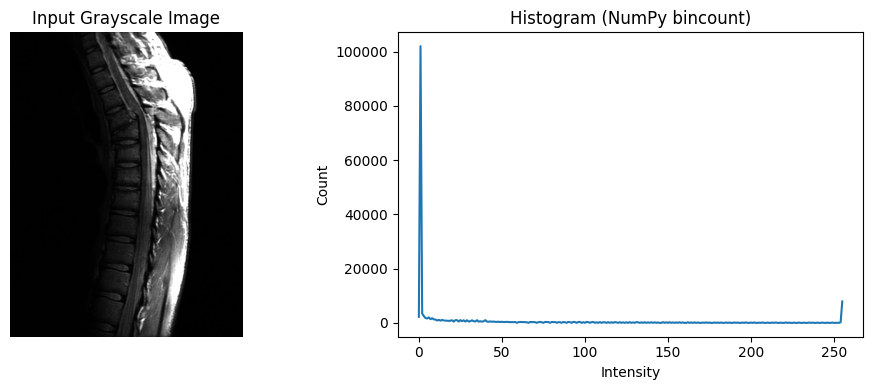

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
# Image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Input Grayscale Image")
plt.axis("off")
# Histogram
plt.subplot(1, 2, 2)
plt.plot(hist_np)
plt.title("Histogram (NumPy bincount)")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [38]:
import numpy as np
# 1) Histogram + normalized
hist = np.bincount(img.ravel(), minlength=256)
p = hist / hist.sum()
# 2) CDF
cdf = np.cumsum(p) # length 256, in [0,1]
# 3) Mapping table (LUT)
lut = np.floor(255 * cdf).astype(np.uint8)
# 4) Apply LUT: new image g(x,y) = lut[f(x,y)]
img_he_np = lut[img]

In [39]:
import cv2
# OpenCV global histogram equalization
img_he_cv = cv2.equalizeHist(img)

In [40]:
from skimage import exposure
import numpy as np
# scikit-image expects float in [0,1] for many functions
f = img.astype(np.float32) / 255.0
img_he_sk = exposure.equalize_hist(f) # float in [0,1]
img_he_sk_u8 = (255.0 * img_he_sk).clip(0, 255).astype(np.uint8)

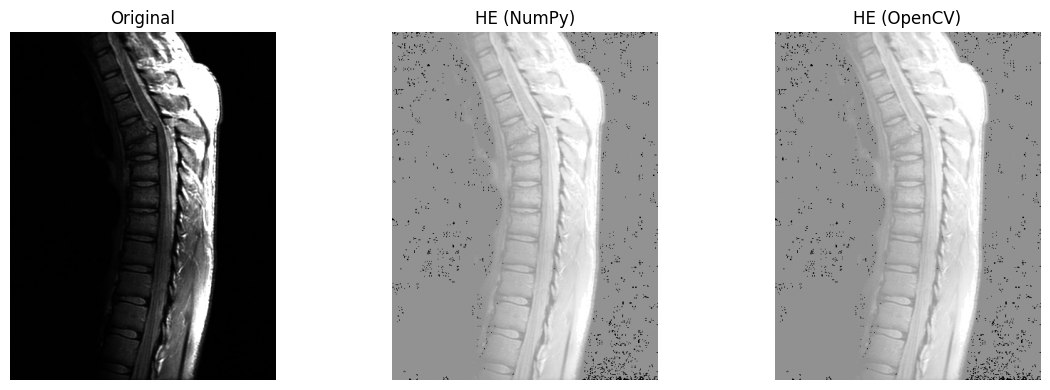

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(img_he_np, cmap="gray", vmin=0, vmax=255)
plt.title("HE (NumPy)")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(img_he_cv, cmap="gray", vmin=0, vmax=255)
plt.title("HE (OpenCV)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [42]:
import numpy as np
T = 128 # example threshold
img_thr_np = np.where(img >= T, 255, 0).astype(np.uint8)

In [43]:
import cv2
T = 128
_, img_thr_cv = cv2.threshold(img, T, 255, cv2.THRESH_BINARY)

In [44]:
import numpy as np
hist = np.bincount(img.ravel(), minlength=256).astype(np.float64)
p = hist / hist.sum()
omega = np.cumsum(p) # class probabilities for [0..T]
mu = np.cumsum(p * np.arange(256)) # cumulative mean
mu_t = mu[-1] # global mean
# Between-class variance for all thresholds
# sigma_b^2(T) = (mu_t * omega - mu)^2 / (omega*(1-omega))
# Avoid division by zero with a small epsilon or masking.
eps = 1e-12
sigma_b2 = (mu_t * omega - mu) ** 2 / (omega * (1.0 - omega) + eps)
T_otsu = int(np.argmax(sigma_b2))
img_otsu_np = np.where(img >= T_otsu, 255, 0).astype(np.uint8)
print("Otsu threshold (NumPy):", T_otsu)

Otsu threshold (NumPy): 104


In [45]:
from skimage.filters import threshold_otsu
import numpy as np
T = threshold_otsu(img)
img_otsu_sk = (img >= T).astype(np.uint8) * 255

In [46]:
import cv2
# If threshold=0 and we add THRESH_OTSU, OpenCV computes Otsu automatically
_, img_otsu_cv = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

In [47]:
import numpy as np
a, b = 1.3, 15 # example parameters
img_lin_np = (a * img.astype(np.float32) + b)
img_lin_np = np.clip(img_lin_np, 0, 255).astype(np.uint8)

In [48]:
import cv2
a, b = 1.3, 15
img_lin_cv = cv2.convertScaleAbs(img, alpha=a, beta=b)

In [49]:
import numpy as np
gamma = 0.7 # example
f = img.astype(np.float32) / 255.0 # normalize to [0,1]
g = np.power(f, gamma) # apply gamma
img_gamma_np = (255.0 * g).clip(0, 255).astype(np.uint8)

In [50]:
from skimage import exposure
import numpy as np
gamma = 0.7
f = img.astype(np.float32) / 255.0
g = exposure.adjust_gamma(f, gamma=gamma) # returns float in [0,1]
img_gamma_sk = (255.0 * g).clip(0, 255).astype(np.uint8)

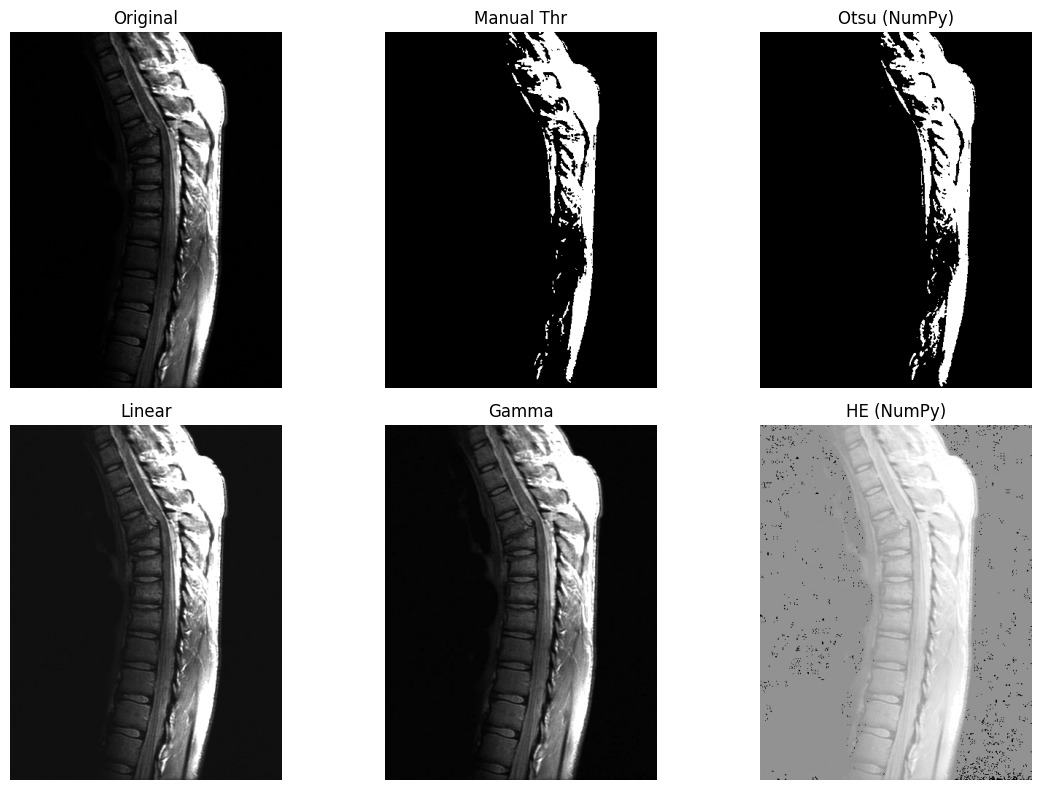

In [51]:
import matplotlib.pyplot as plt
results = [
("Original", img),
("Manual Thr", img_thr_np),
("Otsu (NumPy)", img_otsu_np),
("Linear", img_lin_np),
("Gamma", img_gamma_np),
("HE (NumPy)", img_he_np),
]
plt.figure(figsize=(12, 8))
for i, (name, im) in enumerate(results, 1):
    plt.subplot(2, 3, i)
    plt.imshow(im, cmap="gray", vmin=0, vmax=255)
    plt.title(name)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Exercise 6

## A. Negative / Inversion
Công thức: `g = 255 - f`. Ảnh sáng thành tối và ngược lại.

In [52]:
# NumPy
img_negative_np = 255 - img
print(img_negative_np.dtype, img_negative_np.min(), img_negative_np.max())

uint8 0 255


In [53]:
# OpenCV (phép toán này được OpenCV hỗ trợ trực tiếp)
img_negative_cv = cv2.subtract(255, img)
print(np.array_equal(img_negative_np, img_negative_cv))

True


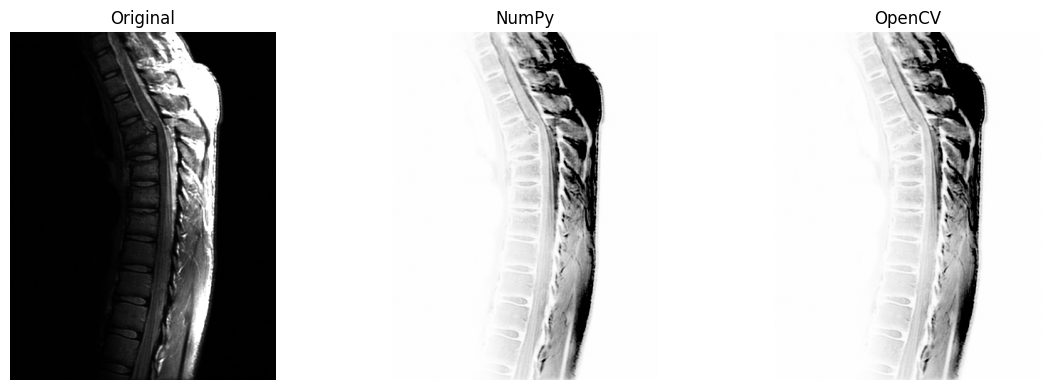

In [54]:
plt.figure(figsize=(12, 4))
for i, (name, im) in enumerate([('Original', img), ('NumPy', img_negative_np), ('OpenCV', img_negative_cv)], 1):
    plt.subplot(1, 3, i); plt.imshow(im, cmap='gray', vmin=0, vmax=255); plt.title(name); plt.axis('off')
plt.tight_layout(); plt.show()

## B. Log transform
Công thức chuẩn hóa: `g = c * log(1 + f)`, sau đó đưa kết quả về `0–255`.

In [55]:
# NumPy
f = img.astype(np.float32) / 255.0
log_np = np.log1p(f)
img_log_np = (255.0 * log_np / log_np.max()).clip(0, 255).astype(np.uint8)

In [56]:
# OpenCV: cv2.log thực hiện log theo từng pixel
log_cv = cv2.log(1.0 + f)
img_log_cv = (255.0 * log_cv / log_cv.max()).clip(0, 255).astype(np.uint8)

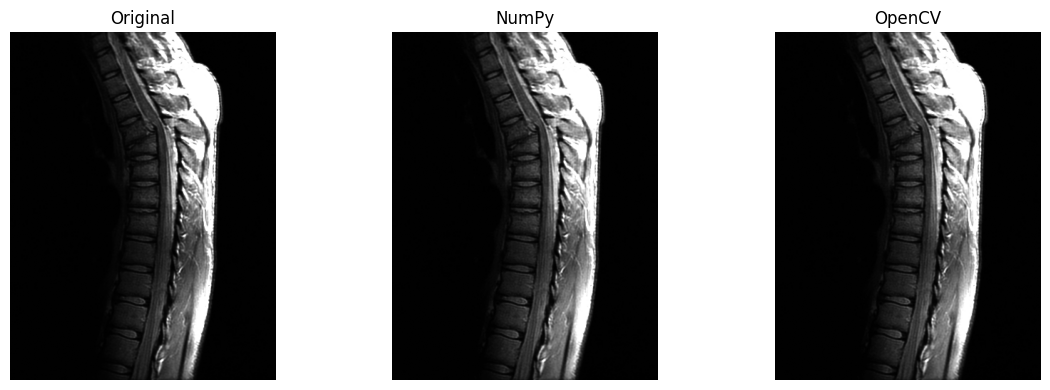

In [57]:
plt.figure(figsize=(12, 4))
for i, (name, im) in enumerate([('Original', img), ('NumPy', img_log_np), ('OpenCV', img_log_cv)], 1):
    plt.subplot(1, 3, i); plt.imshow(im, cmap='gray', vmin=0, vmax=255); plt.title(name); plt.axis('off')
plt.tight_layout(); plt.show()

## C. Contrast stretching theo percentile
Dùng percentile 2% và 98% để giảm ảnh hưởng của điểm quá tối/quá sáng.

In [58]:
# NumPy
p2, p98 = np.percentile(img, (2, 98))
img_stretch_np = ((img.astype(np.float32) - p2) / (p98 - p2)).clip(0, 1)
img_stretch_np = (255 * img_stretch_np).astype(np.uint8)
print(f'P2={p2:.2f}, P98={p98:.2f}')

P2=1.00, P98=255.00


In [59]:
# OpenCV: normalize theo hai mốc percentile
img_stretch_cv = cv2.normalize(img.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX)
# Dùng mask percentile để giữ đúng yêu cầu P2/P98
img_stretch_cv = cv2.normalize(np.clip(img.astype(np.float32), p2, p98), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

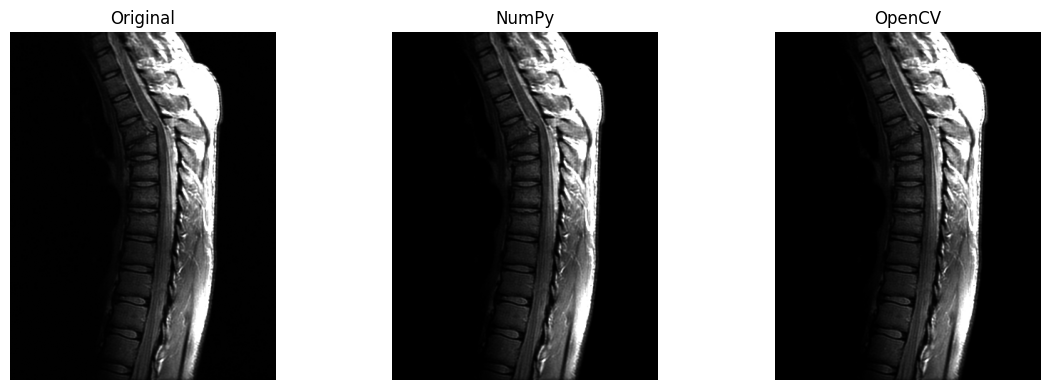

In [60]:
plt.figure(figsize=(12, 4))
for i, (name, im) in enumerate([('Original', img), ('NumPy', img_stretch_np), ('OpenCV', img_stretch_cv)], 1):
    plt.subplot(1, 3, i); plt.imshow(im, cmap='gray', vmin=0, vmax=255); plt.title(name); plt.axis('off')
plt.tight_layout(); plt.show()

## D. Multi-level thresholding
Chọn `T1 < T2`, tạo ba mức: `0`, `127`, `255`.

In [61]:
T1, T2 = 85, 170
# NumPy
img_multi_np = np.where(img < T1, 0, np.where(img < T2, 127, 255)).astype(np.uint8)

In [62]:
# OpenCV: áp dụng hai lần threshold để tạo ba vùng
img_multi_cv = np.zeros_like(img)
img_multi_cv[img >= T1] = 127
img_multi_cv[img >= T2] = 255

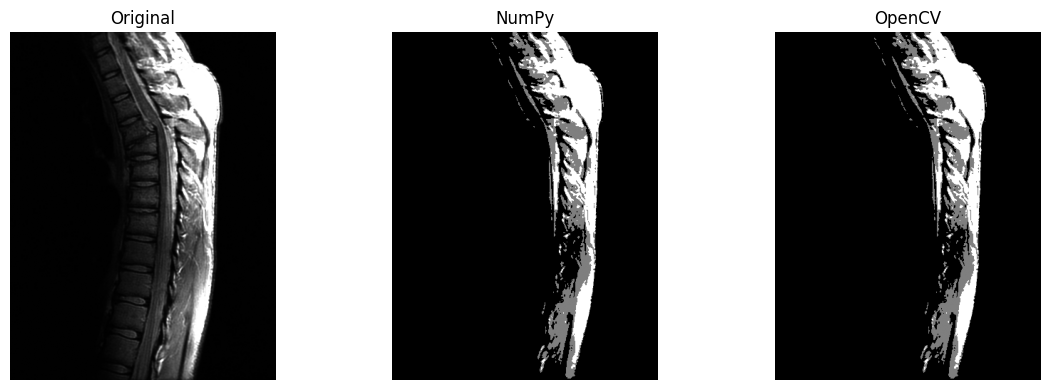

In [63]:
plt.figure(figsize=(12, 4))
for i, (name, im) in enumerate([('Original', img), ('NumPy', img_multi_np), ('OpenCV', img_multi_cv)], 1):
    plt.subplot(1, 3, i); plt.imshow(im, cmap='gray', vmin=0, vmax=255); plt.title(name); plt.axis('off')
plt.tight_layout(); plt.show()

## E. Adaptive thresholding
Ngưỡng được tính cục bộ theo từng vùng, phù hợp khi ảnh có ánh sáng không đều.

In [64]:
# NumPy: local mean bằng integral image
block_size, C = 31, 5
r = block_size // 2
f = img.astype(np.float32)
padded = np.pad(f, ((r, r), (r, r)), mode='reflect')
integral = np.pad(padded, ((1, 0), (1, 0)), mode='constant').cumsum(0).cumsum(1)
local_sum = integral[block_size:, block_size:] - integral[:-block_size, block_size:] - integral[block_size:, :-block_size] + integral[:-block_size, :-block_size]
local_mean = local_sum / (block_size ** 2)
img_adaptive_np = np.where(f > local_mean - C, 255, 0).astype(np.uint8)

In [65]:
# OpenCV: adaptive mean và Gaussian threshold
img_adaptive_mean_cv = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, block_size, C)
img_adaptive_gauss_cv = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, block_size, C)

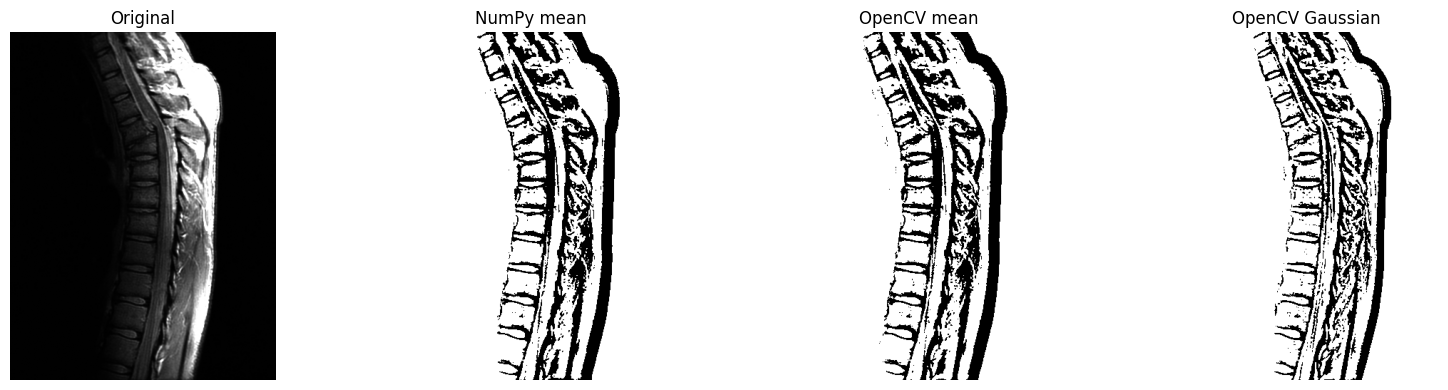

In [66]:
plt.figure(figsize=(16, 4))
for i, (name, im) in enumerate([('Original', img), ('NumPy mean', img_adaptive_np), ('OpenCV mean', img_adaptive_mean_cv), ('OpenCV Gaussian', img_adaptive_gauss_cv)], 1):
    plt.subplot(1, 4, i); plt.imshow(im, cmap='gray', vmin=0, vmax=255); plt.title(name); plt.axis('off')
plt.tight_layout(); plt.show()

# Additional Homework

## 1. Histogram thủ công và đối chiếu thư viện

In [67]:
def histogram_manual(gray_image):
    hist = [0] * 256
    for pixel in gray_image.ravel():
        hist[int(pixel)] += 1
    return np.asarray(hist, dtype=np.int64)

hist_manual = histogram_manual(img)
hist_library = cv2.calcHist([img], [0], None, [256], [0, 256]).ravel().astype(np.int64)
print('Tổng pixel:', hist_manual.sum())
print('Giống OpenCV:', np.array_equal(hist_manual, hist_library))

Tổng pixel: 182024
Giống OpenCV: True


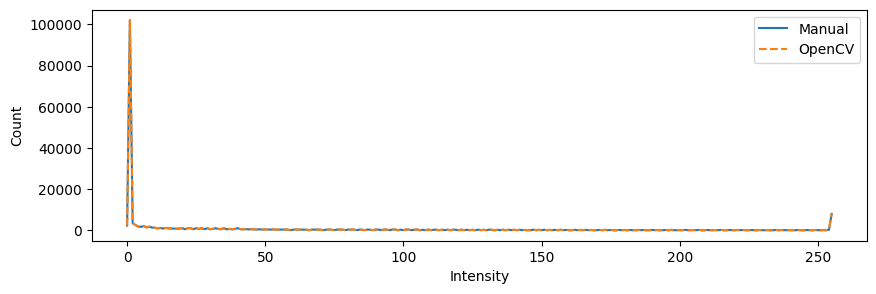

In [68]:
plt.figure(figsize=(10, 3)); plt.plot(hist_manual, label='Manual'); plt.plot(hist_library, '--', label='OpenCV'); plt.xlabel('Intensity'); plt.ylabel('Count'); plt.legend(); plt.show()

## 2. Problem 1 — GrayLevelModification1
Công thức `s = 16 × sqrt(r)`. 

In [69]:
def GrayLevelModification1(gray_image):
    return np.clip(16 * np.sqrt(gray_image.astype(np.float32)), 0, 255).astype(np.uint8)
img_gray_modified = GrayLevelModification1(img)

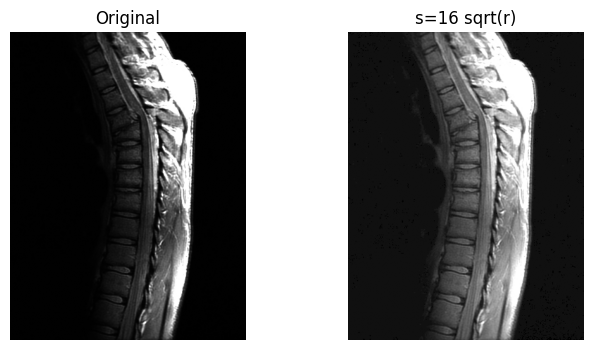

In [70]:
plt.figure(figsize=(8, 4)); plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off'); plt.subplot(1,2,2); plt.imshow(img_gray_modified, cmap='gray'); plt.title('s=16 sqrt(r)'); plt.axis('off'); plt.show()

## 3. Problem 2 — MedianThreshold

In [71]:
def MedianThreshold(gray_image):
    threshold = int(np.median(gray_image))
    binary = np.where(gray_image >= threshold, 255, 0).astype(np.uint8)
    return threshold, binary

median_value, img_median = MedianThreshold(img)
print('Median threshold:', median_value)

Median threshold: 1


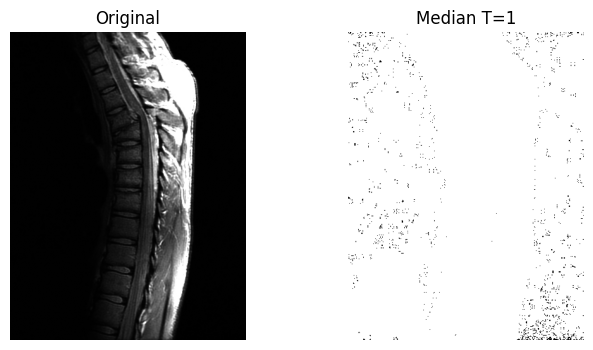

In [72]:
plt.figure(figsize=(8, 4)); plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off'); plt.subplot(1,2,2); plt.imshow(img_median, cmap='gray'); plt.title(f'Median T={median_value}'); plt.axis('off'); plt.show()

## 4. Problem 3 — PowerTransform
Công thức chuẩn hóa `s = 255 × (r/255)^gamma`. `gamma < 1` làm sáng, `gamma > 1` làm tối.

In [73]:
def PowerTransform(gray_image, gamma, c=1.0):
    if gamma <= 0: raise ValueError('gamma phải > 0')
    normalized = gray_image.astype(np.float32) / 255.0
    return (255 * c * np.power(normalized, gamma)).clip(0, 255).astype(np.uint8)

spine = cv2.imread('spine.jpg', cv2.IMREAD_GRAYSCALE)
runway = cv2.imread('runway.jpg', cv2.IMREAD_GRAYSCALE)
if spine is None or runway is None: raise FileNotFoundError('Thiếu spine.jpg hoặc runway.jpg')

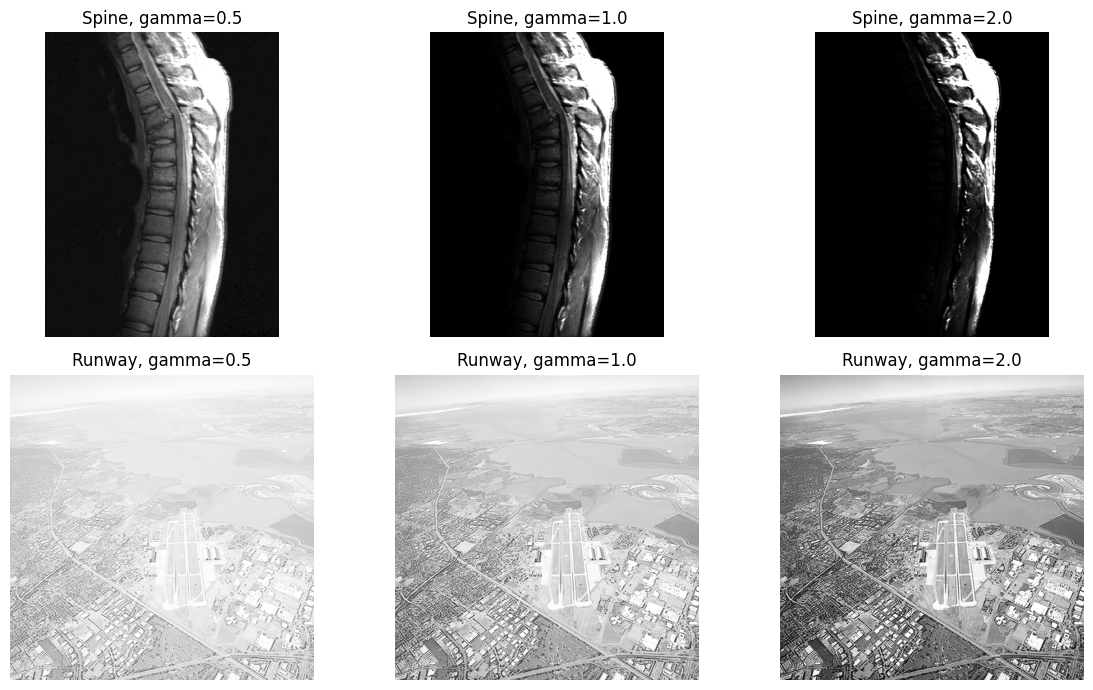

In [74]:
gammas = [0.5, 1.0, 2.0]
plt.figure(figsize=(12, 7))
for row, (name, source) in enumerate([('Spine', spine), ('Runway', runway)]):
    for col, gamma in enumerate(gammas):
        plt.subplot(2, 3, row*3+col+1); plt.imshow(PowerTransform(source, gamma), cmap='gray', vmin=0, vmax=255); plt.title(f'{name}, gamma={gamma}'); plt.axis('off')
plt.tight_layout(); plt.show()